# Figures from Akins and Hofstadter 2026
## 3. Information Content and Vertical Resolution

### Imports 


In [ ]:
import pickle 
import numpy as np 
from numba import njit 
import scipy.constants as spc
import scipy.interpolate as spi 
import matplotlib.pyplot as plt 
import matplotlib.colors as colors
from matplotlib import ticker 
from tqdm.auto import tqdm 

import sys
sys.path.append('/Users/akins/Documents/Codes/ECCM_MRTM')
import eccm 
import mrtm

plt.style.use('~/Documents/Research/Akins.mplstyle')
%matplotlib widget

def degrees_of_freedom(ev): 
    ds = np.sum(ev**2 / (1 + ev**2))
    dn = np.sum(1 / (1 + ev**2))
    return ds, dn 

def shannon_information(ev): 
    H = 0.5 * np.sum(np.log(1 + ev**2))
    return H 

@njit(fastmath=True)
def get_BG_average(K, z):
    # Backus Gilbert averaging kernel, returns averaging kernel and spread 
    # K should be nmeas*nvert
    
    kvec = np.empty(len(K))
    for i, krow in enumerate(K): 
        kvec[i] = np.trapz(krow, z)
    kvec = kvec[:, np.newaxis]
    
    a = np.empty(K.shape)
    
    for i, zz in enumerate(z): 
        Rkl = np.zeros((K.shape[0], K.shape[0]))
        for k, kk in enumerate(K): 
            for l, ll in enumerate(K): 
                Rkl[k, l] = 12 * np.trapz((zz - z)**2 * kk * ll, z)
        Rinv = np.linalg.pinv(Rkl)
        a[:, i] = ((Rinv @ kvec) / (kvec.T @ Rinv @ kvec)).ravel()
    
    A = np.zeros((len(z), len(z)))
    for i, zz in enumerate(z): 
        for j, zzz in enumerate(z): 
            A[i, j] = np.sum(a[:, i] * K[:, j])
            
    return A

@njit(fastmath=True)
def get_BG_spread(K, z):
    # Backus Gilbert spread metric
    # K should be nmeas*nvert
    
    kvec = np.empty(len(K))
    for i, krow in enumerate(K): 
        kvec[i] = np.trapz(krow, z)
    kvec = kvec[:, np.newaxis]
    s = np.empty((1, len(z)))
    for i, zz in enumerate(z): 
        Rkl = np.zeros((K.shape[0], K.shape[0]))
        for k, kk in enumerate(K): 
            for l, ll in enumerate(K): 
                Rkl[k, l] = 12 * np.trapz((zz - z)**2 * kk * ll, z)
        Rinv = np.linalg.pinv(Rkl)
        s[:, i] = (1 / (kvec.T @ Rinv @ kvec)).ravel()
 
    return s.ravel()


## Saturn

### Make reference atmosphere

In [2]:
p_grid = np.logspace(2, 10, 10000)
saturn_gravity = 10.44  # m/s2 
planet_radius = 60268  # km 

# Reference case
saturn_ro = np.loadtxt('/Users/akins/Documents/Codes/ECCM_MRTM/data/ro_profiles/saturn_cassini_schinder2011.txt', skiprows=3, delimiter=',')
saturn_pressure = saturn_ro[:, 0] * 1e2  # Pa
saturn_temperature = saturn_ro[:, 1]


gases1 = eccm.solar_to_deep_mole_fraction(10) 
gases2 = eccm.solar_to_deep_mole_fraction(3) 
deep_h2o = gases1['H2O']
deep_nh3 = gases2['NH3']
deep_h2s = gases1['H2S']
deep_ch4 = gases1['CH4']
deep_ph3 = 0. # gases1['PH3']
h2o_rh = 0.7
h2s_rh = 0.7

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 deep_h2o, deep_nh3, deep_h2s, deep_ch4, deep_ph3, 0.88, 0.12,
                                                 nh3_rh = 0.7, h2o_rh = 0.7,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)

### Make frequency and incidence angle grids 

In [4]:
# Make a list of all possible combinations of channels (5% < BW < 25%, lower bound is 1 ch.)
N = 2
cbw = 0.25
freq_list = [] 
BW_list = [] 
cbw_list = [] 

# Max channel BW is 25%, min is 5% 
while cbw >= 0.05: 
    freq_ghz = np.logspace(np.log10(0.1), np.log10(100), N) # GHz 
    # Get either true channel spacing or 0.25 of center frequency as the channel bandwidth
    BWG = np.gradient(freq_ghz)
    BWF = 0.25 * freq_ghz 
    BW = np.minimum(BWF, BWG)
    # Update the decision criteria
    amin = np.argmin(BW)
    cbw = BW[amin] / freq_ghz[amin]
    cbw_list.append(cbw)
    freq_list.append(freq_ghz)
    BW_list.append(BW)
    N += 1 
incang_list = [np.linspace(0, 60, N) for N in range(1, 8)]


### Compute weighting functions over representative set 

In [4]:
# Run the radiative transfer code once for the maximum frequency coverage, for all incidence angles 
weights = []
Tups = [] 
for k, incang in enumerate(tqdm(incang_list[-1])): 
    full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_list[-1], incang, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
    weights.append(weight_up)
    Tups.append(Tup)
weights = np.stack(weights) 
Tups = np.stack(Tups) 
output_dict = {'incang': incang_list[-1], 
               'freq_ghz': freq_list[-1], 
               'weights': weights, 
               'Tups': Tups}

pickle.dump(output_dict, open('saturn_weights_for_infocontent.p', 'wb'))

  0%|          | 0/7 [00:00<?, ?it/s]

### Set up weighting function interpolators 

In [9]:
weight_dict = pickle.load(open('saturn_weights_for_infocontent.p', 'rb'))
weight_interps = {} 
Tup_interps = {} 

# for k, incang in enumerate(tqdm(weight_dict['incang'])): 
    # 1d interpolators - frequency
    # this_weight_interp = spi.interp1d(weight_dict['freq_ghz'], weight_dict['weights'][k], axis=0, bounds_error=False, fill_value=0) 
    # this_Tup_interp = spi.interp1d(weight_dict['freq_ghz'], weight_dict['Tups'][k], axis=0, bounds_error=False, fill_value=0) 
    # weight_interps[incang] = this_weight_interp 
    # Tup_interps[incang] = this_Tup_interp 
    # 2d interpolators - frequency, incidence angle 

this_weight_interp = spi.RegularGridInterpolator((weight_dict['incang'], weight_dict['freq_ghz']), weight_dict['weights'], bounds_error=False, fill_value=0) 
this_Tup_interp = spi.RegularGridInterpolator((weight_dict['incang'], weight_dict['freq_ghz']), weight_dict['Tups'], bounds_error=False, fill_value=0) 

this_weight_interp((incang, freq_list[2])).shape
this_Tup_interp((incang, freq_list[2])).shape


(4,)

### Set up the information content problem 

In [10]:
Tsys = 1000 
tint = 1  # s
T_1s = 20  # K, a priori
abscal = 0.02  # From Juno, Janssen
S_a = np.diag(T_1s**2 * np.ones(temperature_grid[slc].shape)) 

ds_list = np.zeros((len(freq_list), len(incang_list)))
dn_list = np.zeros((len(freq_list), len(incang_list)))
H_list = np.zeros((len(freq_list), len(incang_list)))
spread_list = np.zeros((len(freq_list), len(incang_list), len(temperature_grid[slc])))

for i, fl in enumerate(tqdm(freq_list, position=0)): 
    BW = BW_list[i]
    NEDT = Tsys / np.sqrt(tint * BW * 1e9)
    for j, ial in enumerate(incang_list): 
        weights = []
        error_comp = []  
        for k, incang in enumerate(ial): 
            # weight_up = weight_interps[incang](fl) 
            weight_up = this_weight_interp((incang, fl))
            weights.append(weight_up)
            if k == 0: 
                # Absolute nadir TB error
                # Tup = Tup_interps[incang](fl) 
                Tup = this_Tup_interp((incang, fl))
                error_comp.append(Tup * abscal + NEDT)
            else: 
                # Relative angle error 
                error_comp.append(NEDT)

        K = np.vstack(weights)
        S_e = np.diag(np.concatenate(error_comp)) 
        tK = np.linalg.pinv(np.sqrt(S_e)) @ K @ np.sqrt(S_a)
        U, s, vh = np.linalg.svd(tK)
        ds, dn = degrees_of_freedom(s)
        H = shannon_information(s)
        # sz = get_BG_spread(K.copy(), pressure_grid[slc].copy())
        sz = 0. 
        ds_list[i, j] = ds
        dn_list[i, j] = dn
        H_list[i, j] = H
        spread_list[i, j] = sz

chan_num = np.array([len(x) for x in freq_list])
ang_num = np.array([len(x) for x in incang_list])
tdict = {'chan_num': chan_num, 'ang_num': ang_num, 'ds_list': ds_list, 'dn_list': dn_list, 'H_list': H_list, 'spread_list': spread_list, 'pressure_grid_Pa': pressure_grid[slc]}
pickle.dump(tdict, open('saturn_info_analysis.p', 'wb'))

  0%|          | 0/142 [00:00<?, ?it/s]

### Make plots 

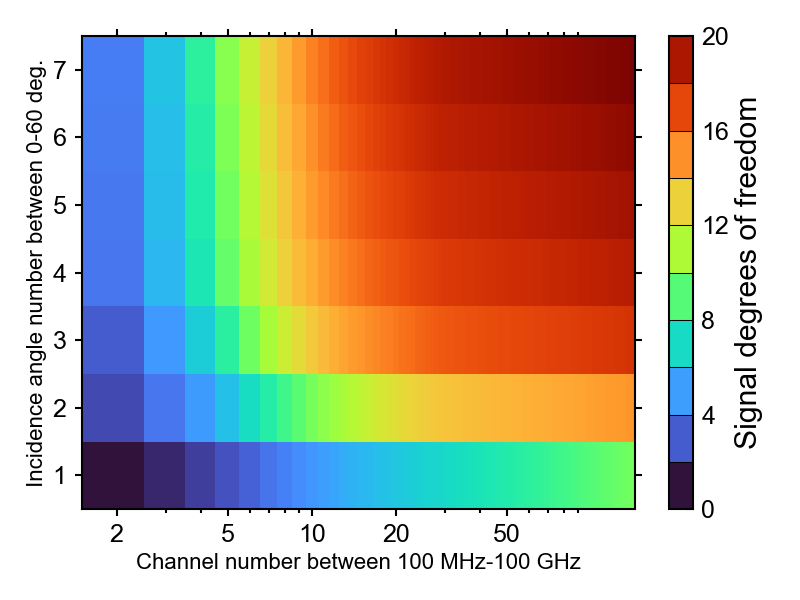

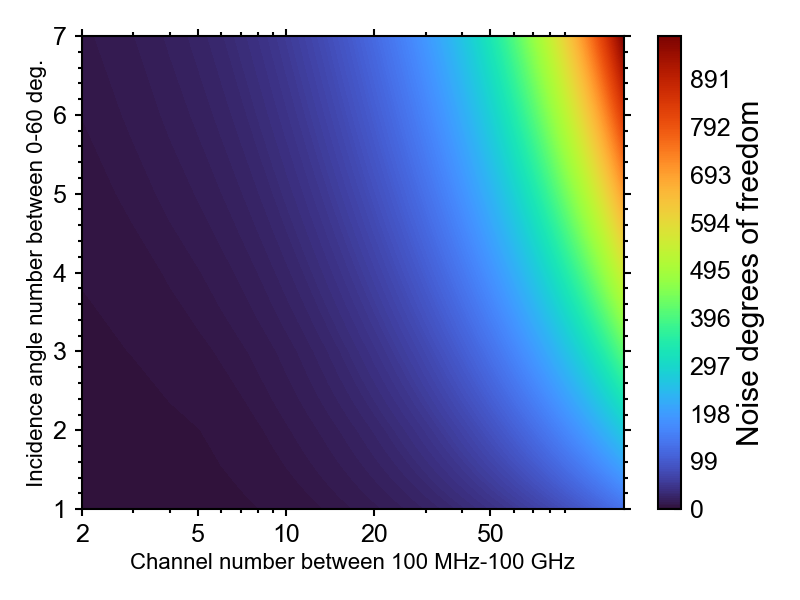

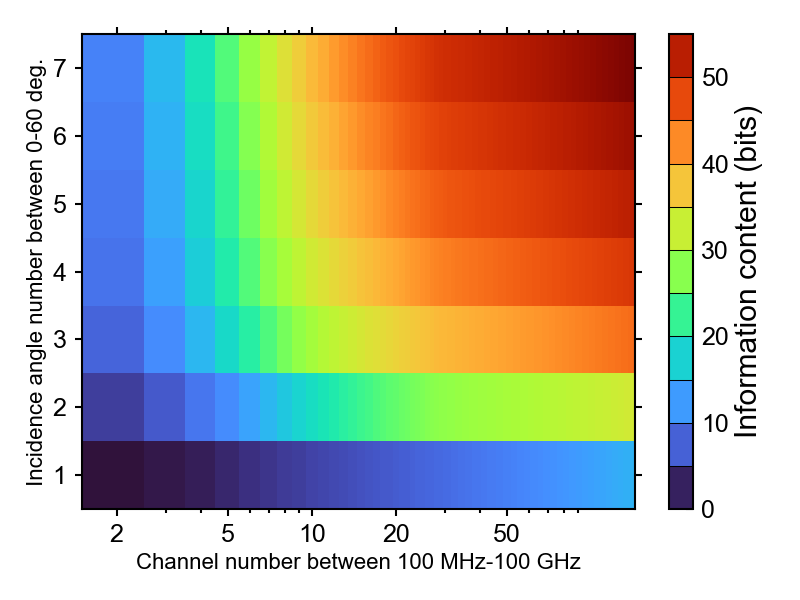

In [20]:
tdict = pickle.load(open('saturn_info_analysis.p', 'rb'))
tdict = {'chan_num': chan_num, 'ang_num': ang_num, 'ds_list': ds_list, 'dn_list': dn_list, 'H_list': H_list}
chan_num = tdict['chan_num']
ang_num = tdict['ang_num']
ds_list = tdict['ds_list']
dn_list = tdict['dn_list']
H_list = tdict['H_list']

# Smooth/Spline some of the lists 
ds_sm = ds_list.copy() 
H_sm = H_list.copy()
for i in range(len(ang_num)): 
    x = np.mgrid[:len(chan_num)]
    # ds_sm[:, i] = ds_list[:, i]
    ds_sm[:, i] = spi.make_smoothing_spline(x, ds_list[:, i])(x)
    # H_sm[:, i] = H_list[:, i]
    H_sm[:, i] = spi.make_smoothing_spline(x, H_list[:, i])(x)


plt.figure()
# plt.contourf(chan_num, ang_num, ds_list.T, cmap='turbo', levels=np.arange(np.round(np.max(ds_list))+1))
plt.pcolormesh(chan_num, ang_num, ds_sm.T, cmap='turbo')
plt.xscale('log')
plt.colorbar(label='Signal degrees of freedom', drawedges=True, boundaries=np.arange(0, np.max(ds_sm), 2))
plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter())
plt.gca().set_xticks([2, 5, 10, 20, 50])
plt.gca().tick_params(axis='both', which='both', direction='out')
plt.gca().tick_params(axis='y', which='minor', left=False, right=False)
plt.xlabel('Channel number between 100 MHz-100 GHz', fontsize=16)
plt.ylabel('Incidence angle number between 0-60 deg.', fontsize=16)
plt.tight_layout()
plt.savefig('saturn_deg_signal.png', dpi=300)

plt.figure()
plt.contourf(chan_num, ang_num, dn_list.T, cmap='turbo', levels=np.arange(np.round(np.max(dn_list))+1))
plt.xscale('log')
plt.colorbar(label='Noise degrees of freedom')
plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter())
plt.gca().set_xticks([2, 5, 10, 20, 50])
plt.gca().tick_params(axis='both', which='both', direction='out')
plt.xlabel('Channel number between 100 MHz-100 GHz', fontsize=16)
plt.ylabel('Incidence angle number between 0-60 deg.', fontsize=16)
plt.tight_layout()
plt.savefig('saturn_deg_noise.png', dpi=300)

plt.figure()
# plt.contourf(chan_num, ang_num, H_list.T, cmap='turbo', levels=np.arange(np.round(np.max(H_list))+1))
plt.pcolormesh(chan_num, ang_num, H_sm.T, cmap='turbo')
plt.xscale('log')
plt.colorbar(label='Information content (bits)', drawedges=True, boundaries=np.arange(0, np.max(H_sm), 5))
plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter())
plt.gca().set_xticks([2, 5, 10, 20, 50])
plt.gca().tick_params(axis='both', which='both', direction='out')
plt.gca().tick_params(axis='y', which='minor', left=False, right=False)
plt.xlabel('Channel number between 100 MHz-100 GHz', fontsize=16)
plt.ylabel('Incidence angle number between 0-60 deg.', fontsize=16)
plt.tight_layout()
plt.savefig('saturn_info_content.png', dpi=300)

### Vertical resolution

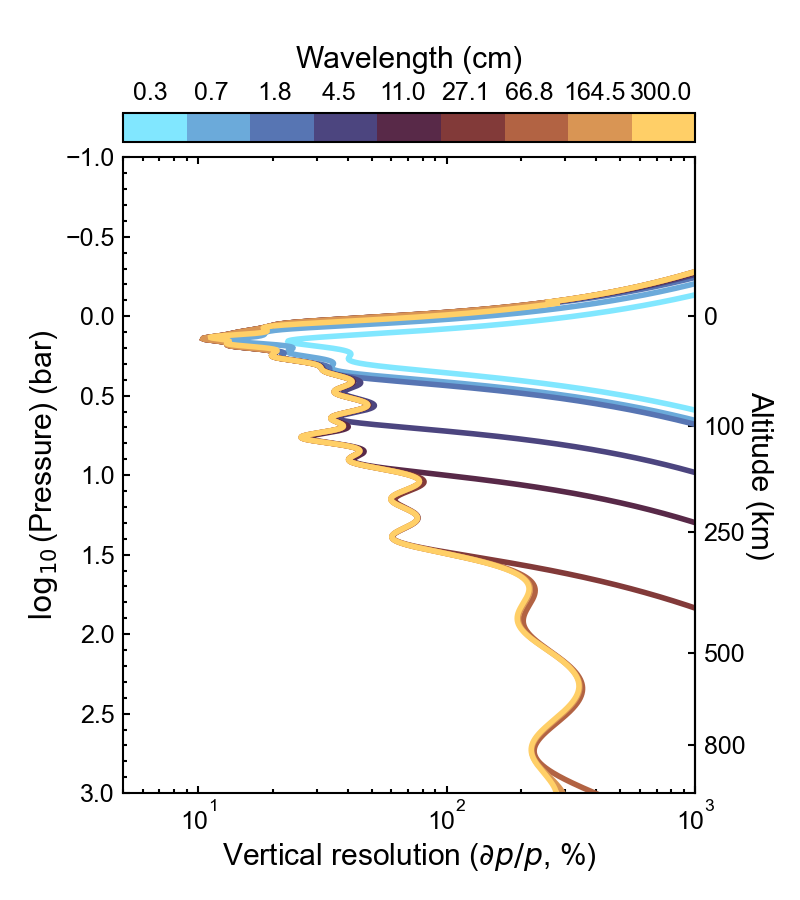

In [ ]:
def p_to_z(x):
    return np.interp(x, np.log10(pressure_grid / spc.bar)[::-1], altitude_grid[::-1])

def z_to_p(x): 
    return np.interp(x, altitude_grid[::-1], np.log10(pressure_grid / spc.bar)[::-1])

planet_radius = 60268  # Saturn

freq_ghz = spc.c / 1e9 / np.logspace(np.log10(3e-3), np.log10(3), 24)
freq_ghz = np.append(freq_ghz, spc.c / 1e9 / 3)  # Staple 3m at the end 
freq_ghz = freq_ghz[::3] 
wave_cm = spc.c / (freq_ghz * 1e9) * 1e2 


incang_deg = 0. 
# Don't need to use the full atmosphere grid
minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
# full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
incang_deg = 50. 
#full_tau2, weight_up2, weight_limb2, Tup2, Tlimb2 = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)

fig = plt.figure(figsize=(8, 9)) 
ax = fig.add_subplot(1, 1, 1) 

# Colormap setup
n_colors = len(wave_cm)
cmap = plt.get_cmap('managua_r', n_colors)  # Discrete version of colormap

edges = np.concatenate([np.array([np.min(wave_cm) - 0.01]), 
                        (wave_cm[:-1] + wave_cm[1:]) / 2, 
                        np.array([np.max(wave_cm) + 0.01])]) 

norm = colors.BoundaryNorm(edges, ncolors=n_colors)

for i in range(len(weight_up)): 
    wave = wave_cm[i]
    color = cmap(norm(wave))
    all_wts = np.vstack([weight_up[:i+1], weight_up2[:i+1]])
    sz = get_BG_spread(all_wts.copy(), pressure_grid[slc].copy())
    ax.plot(-sz / pressure_grid[slc] * 1e2, np.log10(pressure_grid[slc] / spc.bar), color=color, lw=4)

ax.set_xlabel(r'Vertical resolution ($\partial p/p$, %)')
ax.set_ylabel(r'$\log_{10}$(Pressure) (bar)')
ax.set_xlim(5e0, 1e3)
ax.set_ylim(-1, 3)
ax.invert_yaxis()
ax.set_xscale('log')
ax.tick_params(right=False, which='both')
secax = ax.secondary_yaxis('right', functions=(p_to_z, z_to_p))
secax.set_ylabel('Altitude (km)', rotation=-90, labelpad=20) 
secax.yaxis.set_major_formatter(ticker.ScalarFormatter())
secax.set_yticks([-250, -100, 0, 100, 250, 500, 800])
secax.tick_params(right=False, which='minor')

# Colorbar 
tick_locs = np.sqrt(edges[:-1] * edges[1:])
tick_labels = ['{:.1f}'.format(f) for f in wave_cm]
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(
    sm, ax=ax, orientation='horizontal', location='top', pad=0.02,
    boundaries=edges, ticks=tick_locs
)
cbar.set_label('Wavelength (cm)', labelpad=10)
cbar.ax.set_xticklabels(tick_labels)

fig.tight_layout() 
fig.savefig('saturn_vertical.png', dpi=300)

## Uranus

### Make reference atmosphere

In [12]:
p_grid = np.logspace(2, 10, 10000)
uranus_gravity = 8.87  # m/s2 
planet_radius = 25559  # km 

uranus_ro = np.loadtxt('/Users/akins/Documents/Codes/ECCM_MRTM/data/ro_profiles/uranus_voyager2_lindal1987.txt', skiprows=3, delimiter=',')
uranus_pressure = uranus_ro[:, 0] * 1e2  # Pa
uranus_temperature = uranus_ro[:, 1]

gases1 = eccm.solar_to_deep_mole_fraction(35) 
gases2 = eccm.solar_to_deep_mole_fraction(50) 
gases3 = eccm.solar_to_deep_mole_fraction(1) 

deep_h2o = gases1['H2O']
deep_nh3 = gases3['NH3']
deep_h2s = gases1['H2S']
deep_ch4 = gases2['CH4']


pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases1['H2O'], gases3['NH3'], gases1['H2S'], gases2['CH4'], 0., 0.85, 0.15,
                                                 h2s_rh=0.35, h2o_rh=0.35, latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)


minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)

### Make frequency and incidence angle grids 

In [7]:
# Make a list of all possible combinations of channels (5% < BW < 25%, lower bound is 1 ch.)
N = 2
cbw = 0.25
freq_list = [] 
BW_list = [] 
cbw_list = [] 

# Max channel BW is 25%, min is 5% 
while cbw >= 0.05: 
    freq_ghz = np.logspace(np.log10(0.1), np.log10(100), N) # GHz 
    # Get either true channel spacing or 0.25 of center frequency as the channel bandwidth
    BWG = np.gradient(freq_ghz)
    BWF = 0.25 * freq_ghz 
    BW = np.minimum(BWF, BWG)
    # Update the decision criteria
    amin = np.argmin(BW)
    cbw = BW[amin] / freq_ghz[amin]
    cbw_list.append(cbw)
    freq_list.append(freq_ghz)
    BW_list.append(BW)
    N += 1 
incang_list = [np.linspace(0, 60, N) for N in range(1, 8)]


### Compute weighting functions over representative set 

In [8]:
# Run the radiative transfer code once for the maximum frequency coverage, for all incidence angles 
weights = []
Tups = [] 
for k, incang in enumerate(tqdm(incang_list[-1])): 
    full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_list[-1], incang, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
    weights.append(weight_up)
    Tups.append(Tup)
weights = np.stack(weights) 
Tups = np.stack(Tups) 
output_dict = {'incang': incang_list[-1], 
               'freq_ghz': freq_list[-1], 
               'weights': weights, 
               'Tups': Tups}

pickle.dump(output_dict, open('uranus_weights_for_infocontent.p', 'wb'))

  0%|          | 0/7 [00:00<?, ?it/s]

### Set up weighting function interpolators 

In [11]:
weight_dict = pickle.load(open('uranus_weights_for_infocontent.p', 'rb'))
weight_interps = {} 
Tup_interps = {} 

# for k, incang in enumerate(tqdm(weight_dict['incang'])): 
    # 1d interpolators - frequency
    # this_weight_interp = spi.interp1d(weight_dict['freq_ghz'], weight_dict['weights'][k], axis=0, bounds_error=False, fill_value=0) 
    # this_Tup_interp = spi.interp1d(weight_dict['freq_ghz'], weight_dict['Tups'][k], axis=0, bounds_error=False, fill_value=0) 
    # weight_interps[incang] = this_weight_interp 
    # Tup_interps[incang] = this_Tup_interp 
    # 2d interpolators - frequency, incidence angle 

this_weight_interp = spi.RegularGridInterpolator((weight_dict['incang'], weight_dict['freq_ghz']), weight_dict['weights'], bounds_error=False, fill_value=0) 
this_Tup_interp = spi.RegularGridInterpolator((weight_dict['incang'], weight_dict['freq_ghz']), weight_dict['Tups'], bounds_error=False, fill_value=0) 

this_weight_interp((incang, freq_list[2])).shape
this_Tup_interp((incang, freq_list[2])).shape

(4,)

### Set up the information content problem 

In [12]:
Tsys = 1000 
tint = 1  # s
T_1s = 20  # K, a priori
abscal = 0.02  # From Juno, Janssen
S_a = np.diag(T_1s**2 * np.ones(temperature_grid[slc].shape)) 

ds_list = np.zeros((len(freq_list), len(incang_list)))
dn_list = np.zeros((len(freq_list), len(incang_list)))
H_list = np.zeros((len(freq_list), len(incang_list)))
spread_list = np.zeros((len(freq_list), len(incang_list), len(temperature_grid[slc])))

for i, fl in enumerate(tqdm(freq_list, position=0)): 
    BW = BW_list[i]
    NEDT = Tsys / np.sqrt(tint * BW * 1e9)
    for j, ial in enumerate(incang_list): 
        weights = []
        error_comp = []  
        for k, incang in enumerate(ial): 
            # weight_up = weight_interps[incang](fl) 
            weight_up = this_weight_interp((incang, fl))
            weights.append(weight_up)
            if k == 0: 
                # Absolute nadir TB error
                # Tup = Tup_interps[incang](fl) 
                Tup = this_Tup_interp((incang, fl))
                error_comp.append(Tup * abscal + NEDT)
            else: 
                # Relative angle error 
                error_comp.append(NEDT)

        K = np.vstack(weights)
        S_e = np.diag(np.concatenate(error_comp)) 
        tK = np.linalg.pinv(np.sqrt(S_e)) @ K @ np.sqrt(S_a)
        U, s, vh = np.linalg.svd(tK)
        ds, dn = degrees_of_freedom(s)
        H = shannon_information(s)
        # sz = get_BG_spread(K.copy(), pressure_grid[slc].copy())
        sz = 0. 
        ds_list[i, j] = ds
        dn_list[i, j] = dn
        H_list[i, j] = H
        spread_list[i, j] = sz

chan_num = np.array([len(x) for x in freq_list])
ang_num = np.array([len(x) for x in incang_list])
tdict = {'chan_num': chan_num, 'ang_num': ang_num, 'ds_list': ds_list, 'dn_list': dn_list, 'H_list': H_list, 'spread_list': spread_list, 'pressure_grid_Pa': pressure_grid[slc]}
pickle.dump(tdict, open('uranus_info_analysis.p', 'wb'))

  0%|          | 0/142 [00:00<?, ?it/s]

### Make plots

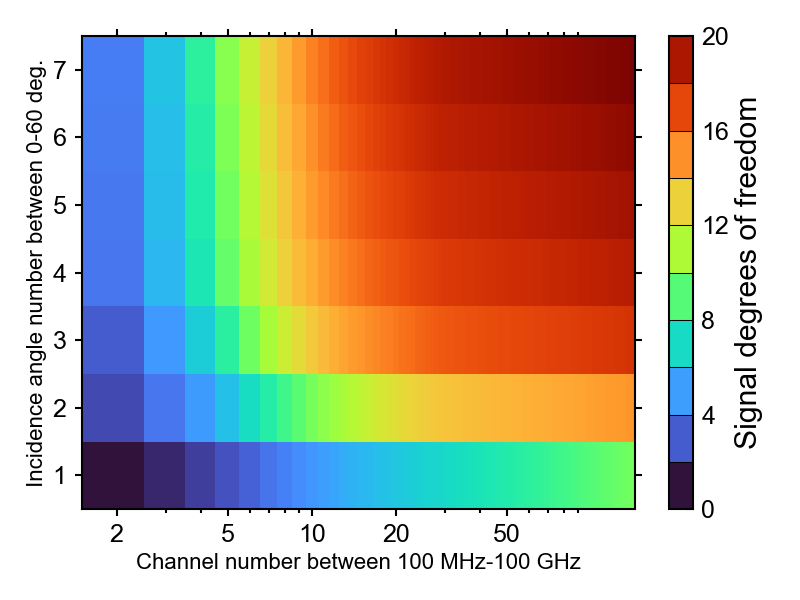

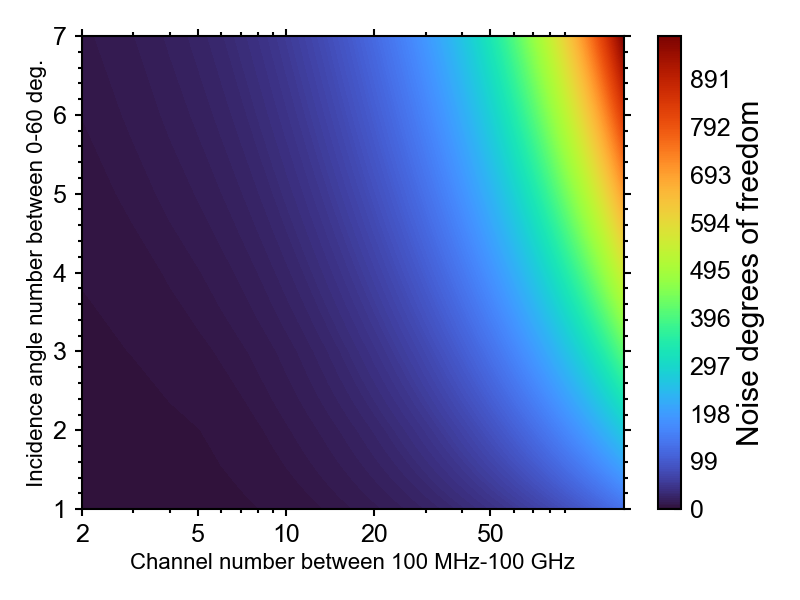

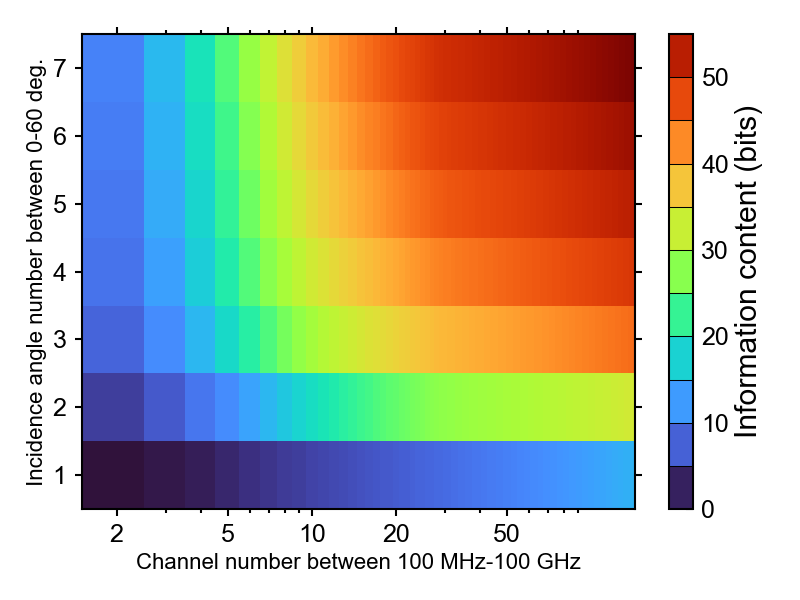

In [21]:
tdict = pickle.load(open('uranus_info_analysis.p', 'rb'))
tdict = {'chan_num': chan_num, 'ang_num': ang_num, 'ds_list': ds_list, 'dn_list': dn_list, 'H_list': H_list}
chan_num = tdict['chan_num']
ang_num = tdict['ang_num']
ds_list = tdict['ds_list']
dn_list = tdict['dn_list']
H_list = tdict['H_list']

# Smooth/Spline some of the lists 
ds_sm = ds_list.copy() 
H_sm = H_list.copy()
for i in range(len(ang_num)): 
    x = np.mgrid[:len(chan_num)]
    # ds_sm[:, i] = ds_list[:, i]
    ds_sm[:, i] = spi.make_smoothing_spline(x, ds_list[:, i])(x)
    # H_sm[:, i] = H_list[:, i]
    H_sm[:, i] = spi.make_smoothing_spline(x, H_list[:, i])(x)


plt.figure()
# plt.contourf(chan_num, ang_num, ds_list.T, cmap='turbo', levels=np.arange(np.round(np.max(ds_list))+1))
plt.pcolormesh(chan_num, ang_num, ds_sm.T, cmap='turbo')
plt.xscale('log')
plt.colorbar(label='Signal degrees of freedom', drawedges=True, boundaries=np.arange(0, np.max(ds_sm), 2))
plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter())
plt.gca().set_xticks([2, 5, 10, 20, 50])
plt.gca().tick_params(axis='both', which='both', direction='out')
plt.gca().tick_params(axis='y', which='minor', left=False, right=False)
plt.xlabel('Channel number between 100 MHz-100 GHz', fontsize=16)
plt.ylabel('Incidence angle number between 0-60 deg.', fontsize=16)
plt.tight_layout()
plt.savefig('uranus_deg_signal.png', dpi=300)

plt.figure()
plt.contourf(chan_num, ang_num, dn_list.T, cmap='turbo', levels=np.arange(np.round(np.max(dn_list))+1))
plt.xscale('log')
plt.colorbar(label='Noise degrees of freedom')
plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter())
plt.gca().set_xticks([2, 5, 10, 20, 50])
plt.gca().tick_params(axis='both', which='both', direction='out')
plt.xlabel('Channel number between 100 MHz-100 GHz', fontsize=16)
plt.ylabel('Incidence angle number between 0-60 deg.', fontsize=16)
plt.tight_layout()
plt.savefig('uranus_deg_noise.png', dpi=300)

plt.figure()
# plt.contourf(chan_num, ang_num, H_list.T, cmap='turbo', levels=np.arange(np.round(np.max(H_list))+1))
plt.pcolormesh(chan_num, ang_num, H_sm.T, cmap='turbo')
plt.xscale('log')
plt.colorbar(label='Information content (bits)', drawedges=True, boundaries=np.arange(0, np.max(H_sm), 5))
plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter())
plt.gca().set_xticks([2, 5, 10, 20, 50])
plt.gca().tick_params(axis='both', which='both', direction='out')
plt.gca().tick_params(axis='y', which='minor', left=False, right=False)
plt.xlabel('Channel number between 100 MHz-100 GHz', fontsize=16)
plt.ylabel('Incidence angle number between 0-60 deg.', fontsize=16)
plt.tight_layout()
plt.savefig('uranus_info_content.png', dpi=300)

## Vertical resolution 

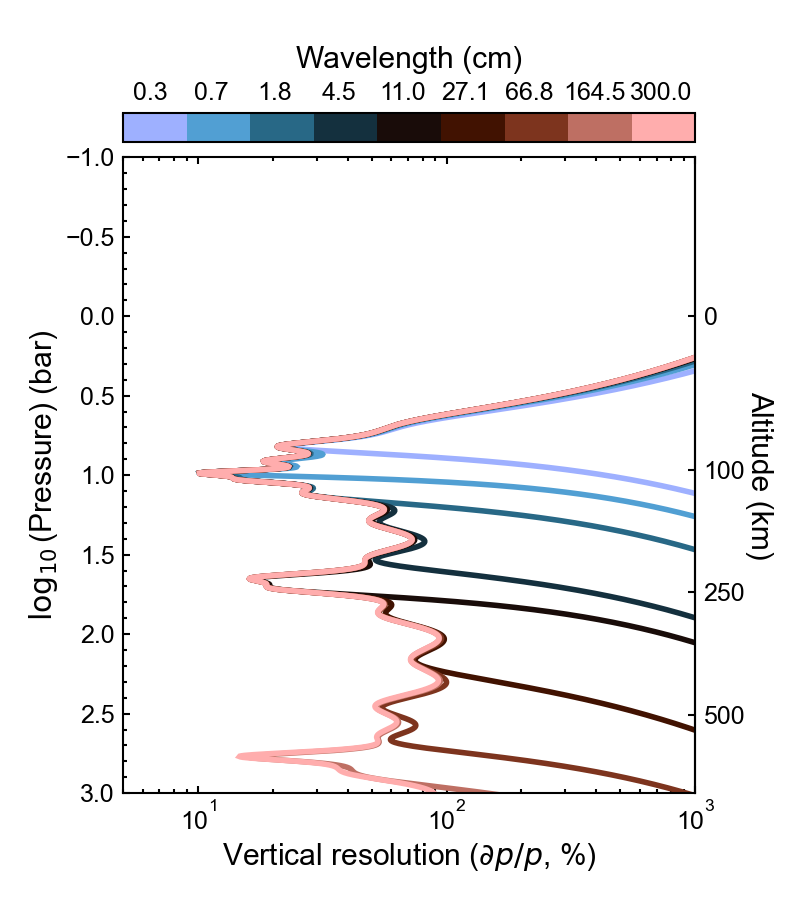

In [13]:
def p_to_z(x):
    return np.interp(x, np.log10(pressure_grid / spc.bar)[::-1], altitude_grid[::-1])

def z_to_p(x): 
    return np.interp(x, altitude_grid[::-1], np.log10(pressure_grid / spc.bar)[::-1])

planet_radius = 25559  # Saturn

freq_ghz = spc.c / 1e9 / np.logspace(np.log10(3e-3), np.log10(3), 24)
freq_ghz = np.append(freq_ghz, spc.c / 1e9 / 3)  # Staple 3m at the end 
freq_ghz = freq_ghz[::3] 
wave_cm = spc.c / (freq_ghz * 1e9) * 1e2 


incang_deg = 0. 
# Don't need to use the full atmosphere grid
minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
incang_deg = 50. 
full_tau2, weight_up2, weight_limb2, Tup2, Tlimb2 = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)

fig = plt.figure(figsize=(8, 9)) 
ax = fig.add_subplot(1, 1, 1) 

# Colormap setup
n_colors = len(wave_cm)
cmap = plt.get_cmap('berlin', n_colors)  # Discrete version of colormap

edges = np.concatenate([np.array([np.min(wave_cm) - 0.01]), 
                        (wave_cm[:-1] + wave_cm[1:]) / 2, 
                        np.array([np.max(wave_cm) + 0.01])]) 

norm = colors.BoundaryNorm(edges, ncolors=n_colors)

for i in range(len(weight_up)): 
    wave = wave_cm[i]
    color = cmap(norm(wave))
    all_wts = np.vstack([weight_up[:i+1], weight_up2[:i+1]])
    sz = get_BG_spread(all_wts.copy(), pressure_grid[slc].copy())
    ax.plot(-sz / pressure_grid[slc] * 1e2, np.log10(pressure_grid[slc] / spc.bar), color=color, lw=4)

ax.set_xlabel(r'Vertical resolution ($\partial p/p$, %)')
ax.set_ylabel(r'$\log_{10}$(Pressure) (bar)')
ax.set_xlim(5e0, 1e3)
ax.set_ylim(-1, 3)
ax.invert_yaxis()
ax.set_xscale('log')
ax.tick_params(right=False, which='both')
secax = ax.secondary_yaxis('right', functions=(p_to_z, z_to_p))
secax.set_ylabel('Altitude (km)', rotation=-90, labelpad=20) 
secax.yaxis.set_major_formatter(ticker.ScalarFormatter())
secax.set_yticks([-250, -100, 0, 100, 250, 500, 800])
secax.tick_params(right=False, which='minor')

# Colorbar 
tick_locs = np.sqrt(edges[:-1] * edges[1:])
tick_labels = ['{:.1f}'.format(f) for f in wave_cm]
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(
    sm, ax=ax, orientation='horizontal', location='top', pad=0.02,
    boundaries=edges, ticks=tick_locs
)
cbar.set_label('Wavelength (cm)', labelpad=10)
cbar.ax.set_xticklabels(tick_labels)

fig.tight_layout() 
fig.savefig('uranus_vertical.png', dpi=300)